--- First 5 Rows of Titanic Dataset ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0       

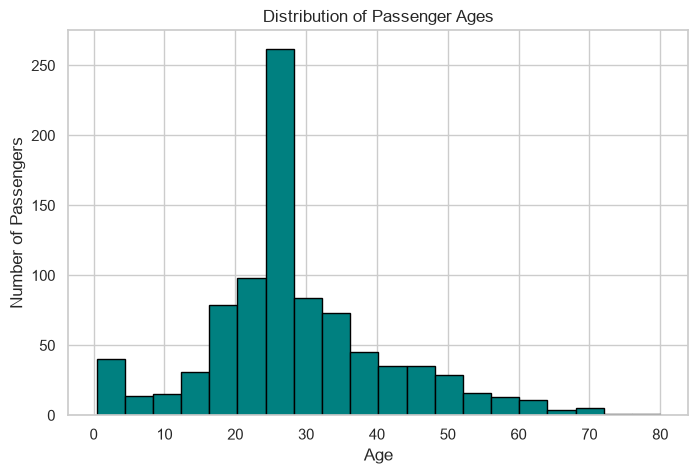

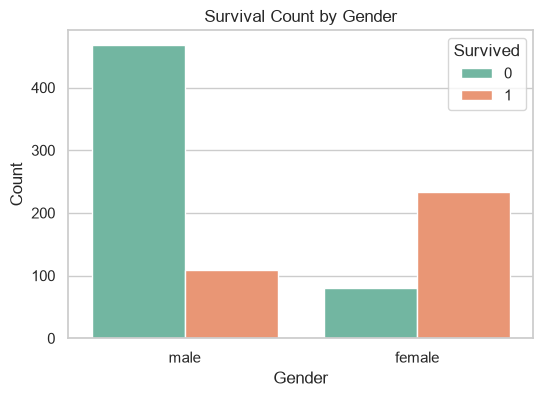

In [3]:
# ==========================================
# STEP 1: IMPORT LIBRARIES & LOAD THE DATA
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

# Open the zip file and read train.csv directly into pandas
with zipfile.ZipFile('titanic.zip', 'r') as z:
    with z.open('train.csv') as f:
        df = pd.read_csv(f)

# Get a first look at the dataset
print("--- First 5 Rows of Titanic Dataset ---")
print(df.head())

print("\n--- Initial Data Information ---")
df.info()

# ==========================================
# STEP 2: IDENTIFY MISSING VALUES & DUPLICATES
# ==========================================
print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()
print(f"\nTotal Duplicate Rows: {duplicate_count}")

# ==========================================
# STEP 3: CLEAN THE DATASET
# ==========================================

# Fill missing Age values with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values with the mode
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)

# Drop Cabin column
df.drop(columns=['Cabin'], inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("\n--- Missing Values After Cleaning ---")
print(df.isnull().sum())

# ==========================================
# STEP 4: SUMMARY STATISTICS
# ==========================================

print("\n--- Descriptive Statistics ---")
print(df.describe())

# Overall survival rate
survival_rate = df['Survived'].mean() * 100
print(f"\nOverall Survival Rate: {survival_rate:.2f}%")

# Passenger count by gender
print("\n--- Passenger Count by Gender ---")
print(df['Sex'].value_counts())

# ==========================================
# STEP 5: VISUALIZATIONS
# ==========================================

sns.set_theme(style="whitegrid")

# Histogram of Passenger Ages
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=20, color='teal', edgecolor='black')
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

# Bar Chart: Survival by Gender
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set2')
plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# Titanic Dataset Data Cleaning and Exploratory Data Analysis
## Import Libraries and Load Dataset
## Identify Missing Values and Duplicate Rows
## Data Cleaning
## Summary Statistics
## Data Visualization